<a href="https://colab.research.google.com/github/JustinMann123/EMSC2010_W2_P1_NB1_u8350605.ipynb/blob/main/major_assesment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Greenland Outline and GPS Station Locations

This section will visualize the Greenland ice sheet using gridded data from `GIS_GMB_grid.nc` and overlay the GPS station locations from `GNET_2025.nc` on a `cartopy` map.

In [11]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 62.8 MB/s eta 0:00:00


In [14]:
print('--- Dataset: GIS_GMB_basin.nc ---')
ds_basin = xr.open_dataset('/content/GIS_GMB_basin.nc')
print(ds_basin)
print('\n--- Variable Information for GIS_GMB_basin.nc ---')
ds_basin.info()



print('--- Dataset: GNET_2025.nc ---')
ds_gnet = xr.open_dataset('/content/GNET_2025.nc')
print(ds_gnet)
print('\n--- Variable Information for GNET_2025.nc ---')
ds_gnet.info()


print('--- Dataset: GIS_GMB_grid.nc ---')
ds_grid_new = xr.open_dataset('/content/GIS_GMB_grid.nc')
print(ds_grid_new)
print('\n--- Variable Information for GIS_GMB_grid.nc ---')
ds_grid_new.info()

--- Dataset: GIS_GMB_basin.nc ---
<xarray.Dataset> Size: 38kB
Dimensions:      (time: 233, reg: 9)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2002-04-18 ... 2024-05-16T12:00:00
Dimensions without coordinates: reg
Data variables:
    time_dec     (time) float64 2kB ...
    regions      (reg) |S5 45B ...
    area         (reg) float64 72B ...
    dm           (reg, time) float64 17kB ...
    sigma_dm     (reg, time) float64 17kB ...
    dmdt         (reg) float64 72B ...
    sigma_dmdt   (reg) float64 72B ...
    gia          (reg) float64 72B ...
    dsldt        (reg) float64 72B ...
    sigma_dsldt  (reg) float64 72B ...
Attributes: (12/16)
    title:                   Greenland Ice Sheet Gravimetric Mass Balance Gri...
    institution:             TU Dresden, Chair of Geodetic Earth System Research
    project:                 Greenland_Ice_Sheet
    source:                  GRACE/GRACE-FO monthly solutions provided by Cen...
    summary:                 GRACE/GRACE-FO-d

In [49]:
import xarray as xr
import pandas as pd
import numpy as np

ds_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')

# Access the 'units' attribute of the 'dm' variable
dm_units = ds_grid['dm'].attrs.get('units')

print(f"The units of the 'dm' variable in GIS_GMB_grid.nc are: {dm_units}")

The units of the 'dm' variable in GIS_GMB_grid.nc are: kg/m^2


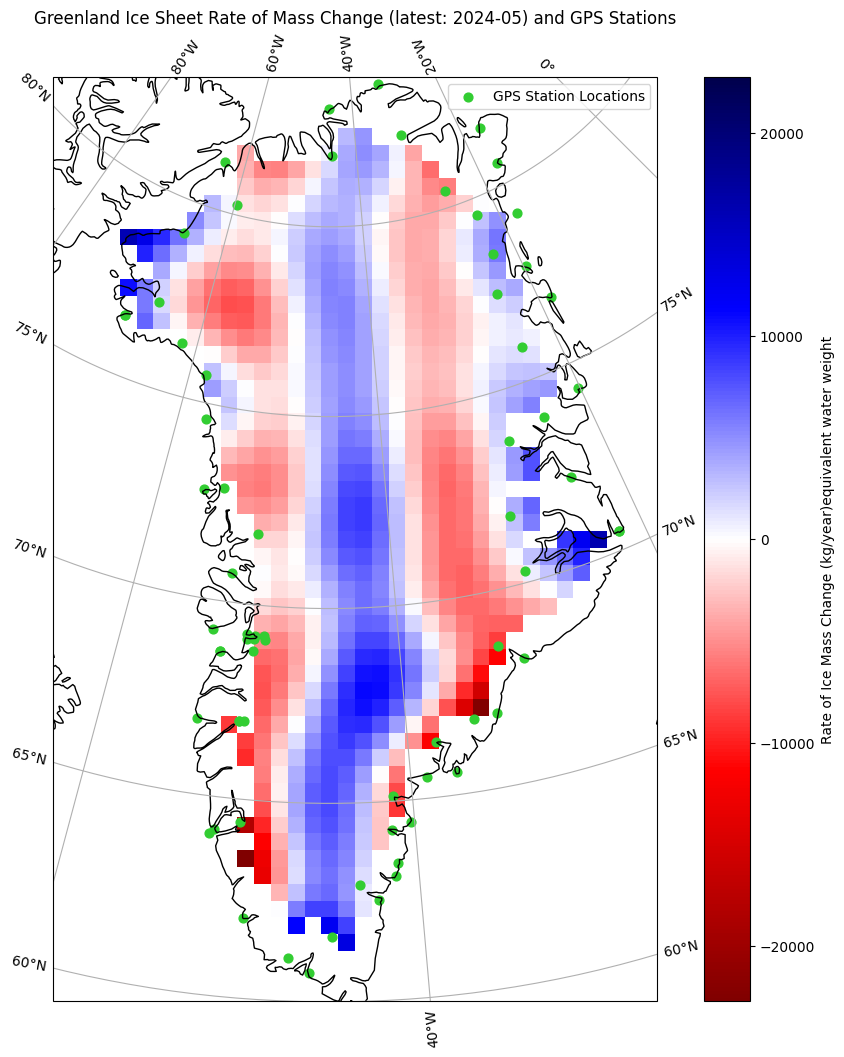

<xarray.DataArray 'dm' (y: 55, x: 36)> Size: 16kB
[1980 values with dtype=float64]
Coordinates:
  * y        (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * x        (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
    time     datetime64[ns] 8B 2002-04-18
Attributes:
    actual_range:   [-12610.9   9044. ]
    long_name:      change in ice mass
    standard_name:  change_in_land_ice_amount
    units:          kg/m^2
<xarray.DataArray 'dm' (y: 55, x: 36)> Size: 16kB
[1980 values with dtype=float64]
Coordinates:
  * y        (y) float64 440B -3.4e+06 -3.35e+06 -3.3e+06 ... -7.5e+05 -7e+05
  * x        (x) float64 288B -8e+05 -7.5e+05 -7e+05 ... 8.5e+05 9e+05 9.5e+05
    time     datetime64[ns] 8B 2024-05-16T12:00:00
Attributes:
    actual_range:   [-12610.9   9044. ]
    long_name:      change in ice mass
    standard_name:  change_in_land_ice_amount
    units:          kg/m^2


In [89]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Load the datasets (re-loading to ensure they are in scope for this cell)
grace_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')
gnet = xr.open_dataset('/content/GNET_2025.nc')

# Prepare grid data for plotting: calculate the rate of mass change (dm/dt)
# The .diff('time') reduces the 'time' dimension by 1. We then select the last available time slice.
rate_of_mass_change = (grace_grid.dm.diff('time') / (grace_grid.time.diff('time').dt.days / 365.25))

# Select the last time step for plotting the current rate of change
latest_rate_data = rate_of_mass_change.isel(time=-1)

# Create a figure and axes with the appropriate Cartopy projection
plt.figure(figsize=(12, 12))
ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=-45))

# Plot the gridded mass change rate data
# We use pcolormesh to plot the 2D gridded data
latest_rate_data.plot.pcolormesh(
    ax=ax,
    x='x', y='y',
    transform=ccrs.NorthPolarStereo(central_longitude=-45), # The data's projection
    cmap='seismic_r',
    cbar_kwargs={'label': f'Rate of Ice Mass Change (kg/year)equivalent water weight'},
    add_colorbar=True
)

# Add geographical features
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Plot station locations from GNET_2025.nc
# Check if 'lat' and 'lon' exist in ds_gnet
if 'lat' in gnet.variables and 'lon' in gnet.variables:
    ax.scatter(
        gnet['lon'], gnet['lat'],
        transform=ccrs.PlateCarree(), # Stations are in lat/lon, so use PlateCarree for source coordinates
        color='limegreen', s=40, label='GPS Station Locations' # Changed 'neonGreen' to 'limegreen'
    )
    plt.legend()
else:
    print("Latitude and Longitude variables not found in GNET_2025.nc")

# Set title, reflecting the rate and the time of the latest data point
plt.title(f'Greenland Ice Sheet Rate of Mass Change (latest: {latest_rate_data.time.dt.strftime("%Y-%m").values}) and GPS Stations')

plt.show()



### show first and last grace signal
print(grace_grid.dm.isel(time=0))
print(grace_grid.dm.isel(time=-1))

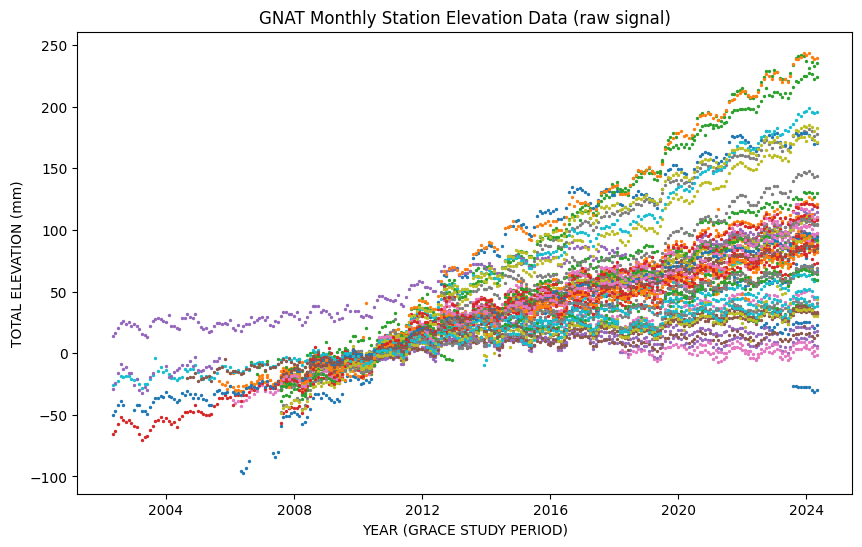

In [93]:
#### plotting raw GNET data
##AI assited with this

## what needs to be done

#Step 1

#open dataset

gnet = xr.open_dataset('/content/GNET_2025.nc')

# step 2 isolate variables

time     = pd.to_datetime(gnet['time'].values)
up       = gnet['up'].values
stations = gnet['station'].values

# clean data to match grace data
##look at previous cell for print function
### start 2002-04-18 End 2024-05-16

study_start = pd.Timestamp('2002-04-18')
study_end   = pd.Timestamp('2024-05-16')

### set a common index
time_index = pd.date_range(study_start, study_end, freq='MS')

### create a new array- for deomstration of what raw data looks like

unormalised = []

## this part is hard as not all of data satrt at the same time and there are 61 diffret GPS stations
## for this reason a loop function needed to be used to loop throught and trim anything out of these bounds

for i, stn in enumerate(stations):
    # (a) slice to GRACE period
    series = pd.Series(up[i], index=time)
    series = series[(series.index >= study_start) & (series.index <= study_end)]

## need to resample the daily measurments to avg monthly as we daily is very noisy--Limitation?

    monthly_Unormalised = series.resample("MS").mean()

### Figure out what this is doing i dare say this is staring them all somwhere??
    monthly1_Unormalised = monthly_Unormalised.reindex(time_index)

#### save into the array

    unormalised.append(monthly1_Unormalised.values)

unormalised_array = np.array(unormalised)

#### with new array created that contians all gnet station monthly elevation data within study periods
#### plot to show for the A3 poster
### this is also hard as there are 61 stations dat that needs to be plotted on that graph
## therfore we need to do a loop plt.scatter

plt.figure(figsize=(10, 6))
for i, stn_data in enumerate(unormalised_array):
  plt.scatter(time_index, stn_data,s=2)
  plt.xlabel('YEAR (GRACE STUDY PERIOD)')
  plt.ylabel('TOTAL ELEVATION (mm)')
  plt.title('GNAT Monthly Station Elevation Data (raw signal)')

# Next step Normalise and avg all GNET data prior to fitting

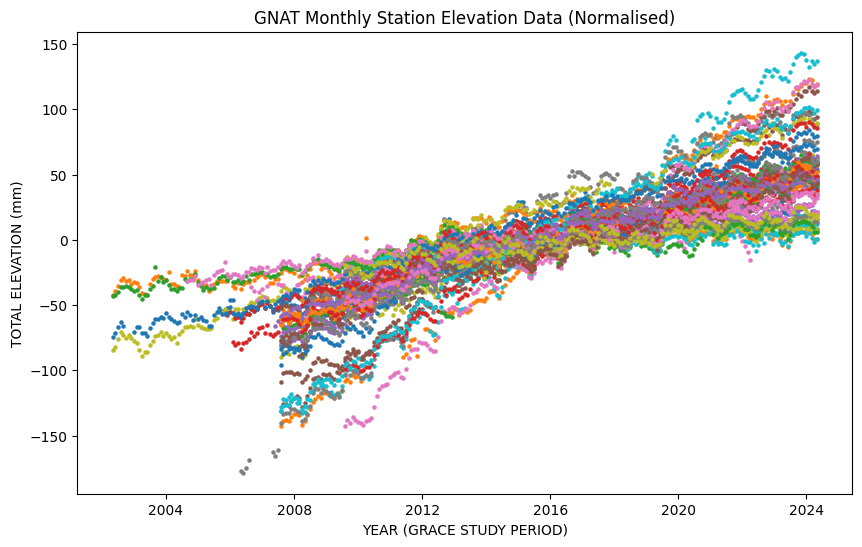

In [102]:
### Simular to the last step but wiht extra step involved

normalised = []

for stn_unnormalised_data in unormalised_array:
  # Convert the numpy array back to a Series for easy use of .dropna() and .mean()
  current_monthly_unnormalised = pd.Series(stn_unnormalised_data, index=time_index)

#### this is to get rid of gp stations that only collected data for less than x months. this cna be removed
  if current_monthly_unnormalised.dropna().__len__() < 60:
    continue # Now 'continue' is inside a loop

  normalised_gnet = current_monthly_unnormalised - current_monthly_unnormalised.mean()
  normalised.append(normalised_gnet.values)

normalised_array = np.array(normalised)
### do we want to get rid of all data that is less than say 3 years ?
# or only include data that spans the entire period

plt.figure(figsize=(10, 6))
for i, stn_data in enumerate(normalised_array):
  plt.scatter(time_index, stn_data,s=5)
  plt.xlabel('YEAR (GRACE STUDY PERIOD)')
  plt.ylabel('TOTAL ELEVATION (mm)')
  plt.title('GNAT Monthly Station Elevation Data (Normalised)')

In [129]:
print(gnet.data_vars)

Data variables:
    decimalyear  (station, time) float32 3MB ...
    east         (station, time) float32 3MB ...
    north        (station, time) float32 3MB ...
    up           (station, time) float32 3MB nan nan nan nan ... nan nan nan nan
    east_error   (station, time) float32 3MB ...
    north_error  (station, time) float32 3MB ...
    up_error     (station, time) float32 3MB ...
    lat          (station) float32 280B ...
    lon          (station) float32 280B ...
    height       (station) float32 280B ...


## convert normalised data to an averaged elastic and GIA rate. ie a rate hopfully representaive of the entire grrenland land mass. 1

ValueError: x and y must be the same size

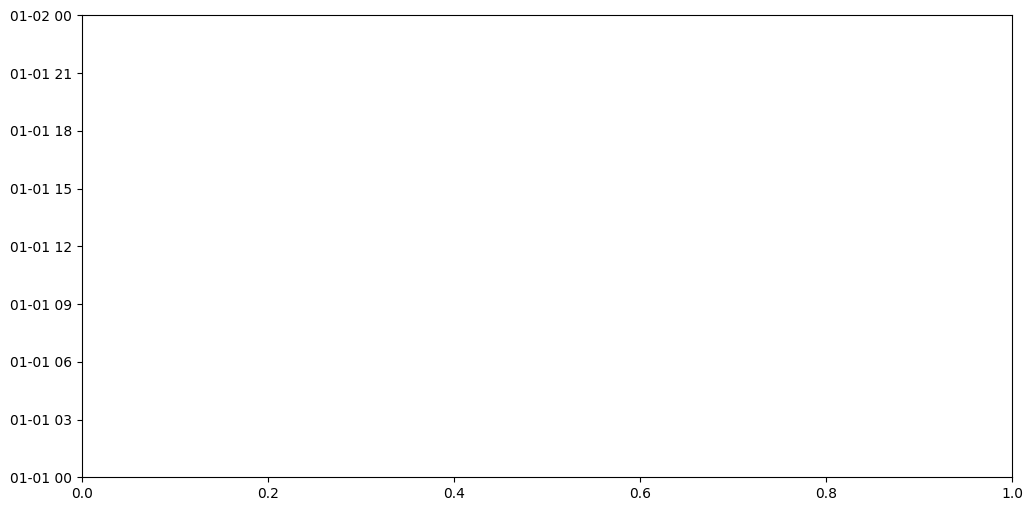

In [136]:
#### need to take the normalised data and take the greenland avg.
## once agin need a loop function to each indavidual time preiod ie all gps
## measurments for 2004-04-1 take the avg
### pretty sure this is called an esembel mean

gnet_elev = grace_grid['dm'].values
gnet_time = grace_grid['time'].values

time_series1 = []
for t in range(gnet_elev.shape[0]):
   avg_gnet_height = gnet_elev[t, :, :]
   time_series1.append(np.nansum(avg_gnet_height)) ## i think beceause there are periods where grace wasnt observing you need to add NAN to this. didnt work wihtout!


plt.figure(figsize=(12, 6))
plt.scatter(gnet_elev, gnet_time, marker='o', linestyle='-', s=4, label='Greenland Total Mass Change')
plt.xlabel('YEAR (GRACE STUDY PERIOD)')
plt.ylabel('Total Mass Change (kg/m^2)')
plt.title('Greenland Total Monthly Mass Change from GRACE')
plt.grid(True)
plt.legend()
plt.show()

Data variables:
    time_dec  (time) float64 2kB ...
    lon       (y, x) float64 16kB ...
    lat       (y, x) float64 16kB ...
    dm        (time, y, x) float64 4MB ...
    area      (y, x) float64 16kB ...
    crs       |S1 1B ...


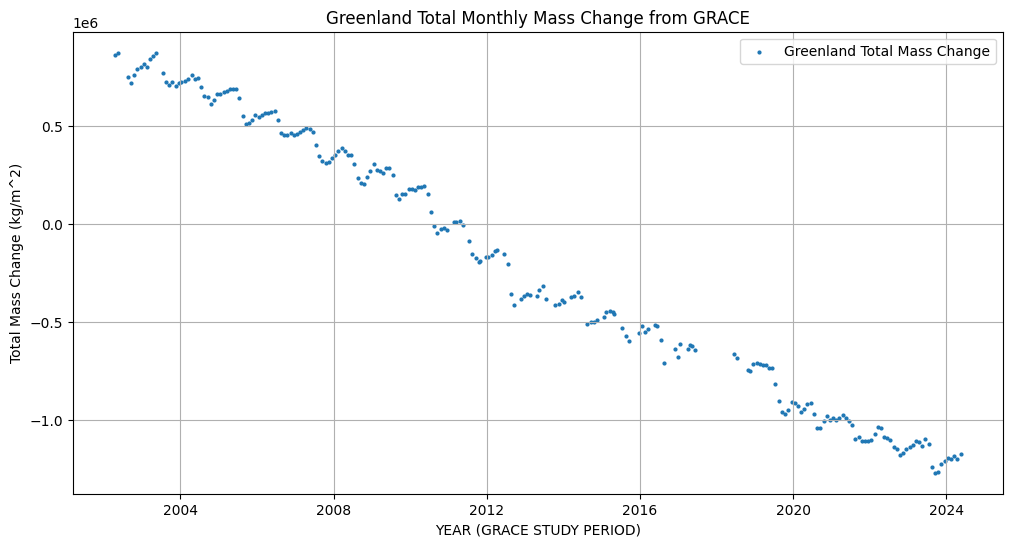

In [127]:
grace_grid = xr.open_dataset('/content/GIS_GMB_grid.nc')

### have to implmet the same loop function to sample monthly mean mass change across all mascons
print(grace_grid.data_vars)
grace_grid.dm

grace_mass = grace_grid['dm'].values
grace_time = grace_grid['time'].values

time_series = []
for t in range(grace_mass.shape[0]):
    kgm2 = grace_mass[t, :, :]
    time_series.append(np.nansum(kgm2)) ## i think beceause there are periods where grace wasnt observing you need to add NAN to this. didnt work wihtout!


plt.figure(figsize=(12, 6))
plt.scatter(grace_time, time_series, marker='o', linestyle='-', s=4, label='Greenland Total Mass Change')
plt.xlabel('YEAR (GRACE STUDY PERIOD)')
plt.ylabel('Total Mass Change (kg/m^2)')
plt.title('Greenland Total Monthly Mass Change from GRACE')
plt.grid(True)
plt.legend()
plt.show()